In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

In [8]:
df = pd.read_csv('processed_data.csv')

X = df.drop('Stars Count', axis='columns')
y = df['Stars Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (2049, 101)
Test shape: (513, 101)


In [9]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

baseline_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2_log': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test_original, y_pred_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
}

pd.DataFrame([baseline_metrics], index=['KNN baseline'])

,MAE_log,RMSE_log,R2_log,MAE,RMSE
KNN baseline,0.532363,0.759339,0.696457,9020.95032,19109.14983


In [10]:
param_grid = {
    'model__n_neighbors': list(range(5, 40, 5)),
    'model__algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV score:', -grid_search.best_score_)

Best params: {'model__algorithm': 'auto', 'model__metric': 'manhattan', 'model__n_neighbors': 25, 'model__weights': 'distance'}
Best CV score: 0.6231187347041518


In [11]:
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_best_original = np.expm1(y_pred_best)


tuned_metrics = {
    'MAE_log': mean_absolute_error(y_test, y_pred_best),
    'RMSE_log': np.sqrt(mean_squared_error(y_test, y_pred_best)),
    'R2_log': r2_score(y_test, y_pred),
    'MAE': mean_absolute_error(y_test_original, y_pred_best_original),
    'RMSE': np.sqrt(mean_squared_error(y_test_original, y_pred_best_original)),
}

pd.DataFrame([
    baseline_metrics,
    tuned_metrics
], index=['KNN baseline', 'KNN tuned'])

,MAE_log,RMSE_log,R2_log,MAE,RMSE
KNN baseline,0.532363,0.759339,0.696457,9020.950320,19109.149830
KNN tuned,0.475908,0.628813,0.696457,8422.675729,17828.846917


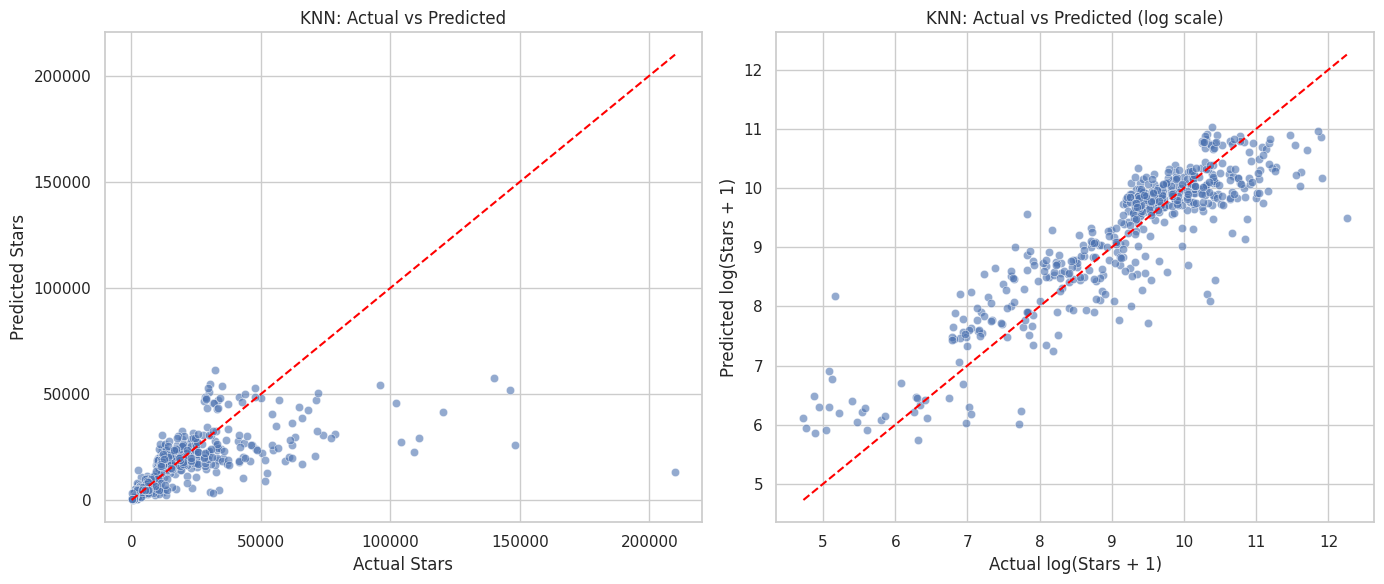

In [12]:
results = pd.DataFrame({
    'Actual_log': y_test,
    'Predicted_log': y_pred_best,
    'Actual': np.expm1(y_test),
    'Predicted': np.expm1(y_pred_best)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=results, x='Actual', y='Predicted', alpha=0.6, ax=axes[0])
axes[0].plot(
    [results['Actual'].min(), results['Actual'].max()],
    [results['Actual'].min(), results['Actual'].max()],
    color='red',
    linestyle='--'
)
axes[0].set_title('KNN: Actual vs Predicted')
axes[0].set_xlabel('Actual Stars')
axes[0].set_ylabel('Predicted Stars')

sns.scatterplot(data=results, x='Actual_log', y='Predicted_log', alpha=0.6, ax=axes[1])
axes[1].plot(
    [results['Actual_log'].min(), results['Actual_log'].max()],
    [results['Actual_log'].min(), results['Actual_log'].max()],
    color='red',
    linestyle='--'
)
axes[1].set_title('KNN: Actual vs Predicted (log scale)')
axes[1].set_xlabel('Actual log(Stars + 1)')
axes[1].set_ylabel('Predicted log(Stars + 1)')

plt.tight_layout()
plt.show()